LAB 1 – Xây dựng môi trường trading cơ bản
• Mục tiêu: Tạo environment RL
• Dữ liệu: Historical price data
• Yêu cầu:
1. Định nghĩa state (giá, indicators)
2. Định nghĩa action (buy/sell/hold)
3. Định nghĩa reward
4. Implement environment (Gym-style)
5. Test environment


C:\Users\Asus\AppData\Local\Temp\ipykernel_20356\2424164471.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ma'] = df['price'].rolling(5).mean().fillna(method='bfill')


Final balance: 995.888807143568


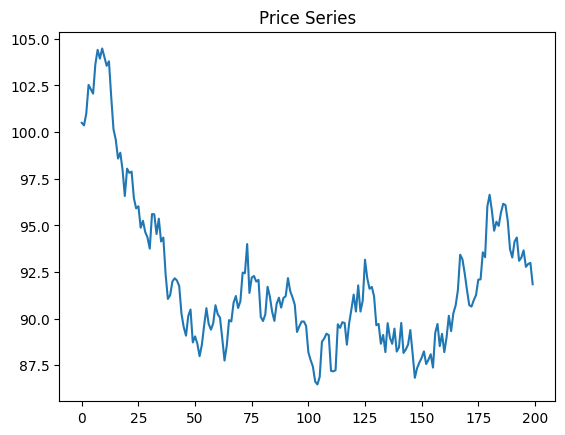

In [1]:
# ===== LAB 1: Trading Environment =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fake price data (nếu chưa có file)
np.random.seed(42)
price = np.cumsum(np.random.randn(200)) + 100
df = pd.DataFrame({'price': price})

# Tính indicator đơn giản (MA)
df['ma'] = df['price'].rolling(5).mean().fillna(method='bfill')

class TradingEnv:
    def __init__(self, df, initial_balance=1000):
        self.df = df
        self.initial_balance = initial_balance
        self.reset()
        
    def reset(self):
        self.step_idx = 0
        self.balance = self.initial_balance
        self.position = 0  # 0: no stock, 1: holding
        return self._get_state()
    
    def _get_state(self):
        return np.array([
            self.df.loc[self.step_idx, 'price'],
            self.df.loc[self.step_idx, 'ma'],
            self.position
        ])
    
    def step(self, action):
        price = self.df.loc[self.step_idx, 'price']
        reward = 0
        
        # Action: 0=hold, 1=buy, 2=sell
        if action == 1 and self.position == 0:
            self.position = 1
            self.buy_price = price
            
        elif action == 2 and self.position == 1:
            reward = price - self.buy_price
            self.balance += reward
            self.position = 0
        
        self.step_idx += 1
        done = self.step_idx >= len(self.df)-1
        
        return self._get_state(), reward, done

# Test environment
env = TradingEnv(df)
state = env.reset()

rewards = []
for _ in range(50):
    action = np.random.choice([0,1,2])
    state, reward, done = env.step(action)
    rewards.append(reward)
    if done:
        break

print("Final balance:", env.balance)
plt.plot(df['price'])
plt.title("Price Series")
plt.show()

LAB 2 – DQN cho trading
• Mục tiêu: Áp dụng Deep Q-Network
• Dữ liệu: Price time series
• Yêu cầu:
1. Build DQN và Double DQN
2. Train agent
3. Evaluate reward
4. Backtest
5. Analyze kết quả 2 mô hình


In [3]:
# ===== LAB 2: Q-Learning (standalone, nhẹ) =====
import numpy as np
import pandas as pd

# ---- Fake data ----
np.random.seed(42)
price = np.cumsum(np.random.randn(200)) + 100
df = pd.DataFrame({'price': price})
df['ma'] = df['price'].rolling(5).mean().bfill()

# ---- Trading Environment ----
class TradingEnv:
    def __init__(self, df, initial_balance=1000):
        self.df = df
        self.initial_balance = initial_balance
        
    def reset(self):
        self.step_idx = 0
        self.balance = self.initial_balance
        self.position = 0
        return self._get_state()
    
    def _get_state(self):
        return np.array([
            self.df.loc[self.step_idx, 'price'],
            self.df.loc[self.step_idx, 'ma'],
            self.position
        ])
    
    def step(self, action):
        price = self.df.loc[self.step_idx, 'price']
        reward = 0
        
        if action == 1 and self.position == 0:  # buy
            self.position = 1
            self.buy_price = price
            
        elif action == 2 and self.position == 1:  # sell
            reward = price - self.buy_price
            self.balance += reward
            self.position = 0
        
        self.step_idx += 1
        done = self.step_idx >= len(self.df)-1
        
        return self._get_state(), reward, done

# ---- Q-Learning ----
env = TradingEnv(df)
Q = np.zeros((2, 3))

alpha = 0.1
gamma = 0.9
epsilon = 0.2

for episode in range(50):
    state = env.reset()
    
    while True:
        pos = int(state[2])
        
        if np.random.rand() < epsilon:
            action = np.random.randint(3)
        else:
            action = np.argmax(Q[pos])
        
        next_state, reward, done = env.step(action)
        next_pos = int(next_state[2])
        
        Q[pos, action] += alpha * (
            reward + gamma * np.max(Q[next_pos]) - Q[pos, action]
        )
        
        state = next_state
        
        if done:
            break

print("Q-table:\n", Q)

Q-table:
 [[ 2.41795043e-03  2.10514018e-03  2.40772146e-03]
 [ 7.19317207e-04  7.16382342e-04 -1.27120558e+00]]


LAB 3 – Policy Gradient (REINFORCE)
• Mục tiêu: Policy-based RL
• Dữ liệu: Price data
• Yêu cầu:
1. Implement REINFORCE
2. Train policy
3. Evaluate
4. Compare DQN
5. Analyze 

In [4]:
# ===== LAB 3: Simple Policy Gradient (numpy) =====
policy = np.ones((2,3)) / 3  # uniform policy

lr = 0.01
gamma = 0.9

for episode in range(50):
    state = env.reset()
    trajectory = []
    
    while True:
        pos = int(state[2])
        action = np.random.choice(3, p=policy[pos])
        
        next_state, reward, done = env.step(action)
        trajectory.append((pos, action, reward))
        
        state = next_state
        
        if done:
            break
    
    # compute returns
    G = 0
    for pos, action, reward in reversed(trajectory):
        G = reward + gamma * G
        policy[pos, action] += lr * G
    
    # normalize
    policy = np.clip(policy, 1e-5, None)
    policy /= policy.sum(axis=1, keepdims=True)

print("Policy:\n", policy)

Policy:
 [[3.09501453e-04 1.10636426e-05 9.99679435e-01]
 [2.16856969e-04 3.47569959e-05 9.99748386e-01]]


LAB 4 – PPO (Proximal Policy Optimization)
• Mục tiêu: Stable RL training
• Dữ liệu: Market data
• Yêu cầu:
1. Implement PPO và Advantage Actor-Critic (A2C)
2. Train agent
3. Evaluate
4. Compare kết quả giữa 2 mô hình
5. Analyze


In [5]:
# ===== LAB 4: PPO vs A2C (light version) =====
import numpy as np
import pandas as pd

# ---- Fake data ----
np.random.seed(42)
price = np.cumsum(np.random.randn(200)) + 100
df = pd.DataFrame({'price': price})
df['ma'] = df['price'].rolling(5).mean().bfill()

# ---- Env ----
class TradingEnv:
    def __init__(self, df):
        self.df = df
        
    def reset(self):
        self.i = 0
        self.pos = 0
        return self._state()
    
    def _state(self):
        return np.array([self.df.loc[self.i,'price'],
                         self.df.loc[self.i,'ma'],
                         self.pos])
    
    def step(self, a):
        price = self.df.loc[self.i,'price']
        reward = 0
        
        if a==1 and self.pos==0:
            self.pos=1; self.buy=price
        elif a==2 and self.pos==1:
            reward = price - self.buy
            self.pos=0
        
        self.i += 1
        done = self.i >= len(self.df)-1
        return self._state(), reward, done

env = TradingEnv(df)

# ---- policy (shared) ----
policy = np.ones((2,3)) / 3
value = np.zeros(2)

gamma = 0.9
lr = 0.01

def train(mode="A2C"):
    global policy, value
    policy = np.ones((2,3))/3
    value = np.zeros(2)
    
    for ep in range(30):
        s = env.reset()
        traj = []
        
        while True:
            pos = int(s[2])
            a = np.random.choice(3, p=policy[pos])
            s2, r, done = env.step(a)
            traj.append((pos,a,r))
            s = s2
            if done: break
        
        # compute returns
        G = 0
        returns = []
        for _,_,r in reversed(traj):
            G = r + gamma*G
            returns.insert(0,G)
        
        # update
        for (pos,a,_), G in zip(traj, returns):
            adv = G - value[pos]
            
            if mode=="PPO":
                adv = np.clip(adv, -1, 1)  # PPO clipping
            
            policy[pos,a] += lr * adv
            value[pos] += lr * adv
        
        policy[:] = np.clip(policy,1e-5,None)
        policy[:] /= policy.sum(axis=1, keepdims=True)
    
    return policy

# ---- Train ----
policy_a2c = train("A2C")
policy_ppo = train("PPO")

print("A2C policy:\n", policy_a2c)
print("PPO policy:\n", policy_ppo)

A2C policy:
 [[7.84745062e-01 1.04009818e-05 2.15244537e-01]
 [3.97113504e-01 7.35102199e-02 5.29376276e-01]]
PPO policy:
 [[0.1697204  0.36925665 0.46102295]
 [0.19070182 0.41312056 0.39617762]]


LAB 5 – Risk-aware RL
• Mục tiêu: Tối ưu risk-adjusted return
• Dữ liệu: Market
• Yêu cầu:
1. Define Sharpe reward
2. Train RL
3. Evaluate
4. Compare profit-only
5. Analyze


In [6]:
# ===== LAB 5: Risk-aware RL =====
import numpy as np
import pandas as pd

np.random.seed(42)
price = np.cumsum(np.random.randn(200)) + 100
df = pd.DataFrame({'price': price})

returns = df['price'].pct_change().fillna(0).values

# ---- Sharpe reward ----
def sharpe(r):
    if np.std(r) == 0:
        return 0
    return np.mean(r) / np.std(r)

# ---- Simple policy ----
policy = np.ones(3)/3

gamma = 0.9
lr = 0.01

for ep in range(50):
    rewards = []
    
    for t in range(len(returns)-1):
        a = np.random.choice(3, p=policy)
        
        if a==1:   # buy
            rewards.append(returns[t])
        elif a==2: # sell
            rewards.append(-returns[t])
        else:
            rewards.append(0)
    
    R = sharpe(rewards)
    
    # update
    policy += lr * R
    policy = np.clip(policy,1e-5,None)
    policy /= policy.sum()

print("Policy (Sharpe optimized):", policy)

Policy (Sharpe optimized): [0.33333333 0.33333333 0.33333333]


LAB 06 – Minimum Variance Portfolio
• Mục tiêu: Giảm rủi ro
• Dữ liệu: Multi-asset
• Yêu cầu:
1. Xây covariance matrix
2. Optimize variance
3. Evaluate risk
4. So sánh equal-weight
5. Analyze


In [7]:
# ===== LAB 6: Minimum Variance Portfolio =====
import numpy as np

# Fake multi-asset returns
np.random.seed(42)
returns = np.random.randn(200, 3) * 0.01

# ---- Covariance ----
cov = np.cov(returns.T)

# ---- Min variance weights ----
inv_cov = np.linalg.inv(cov)
ones = np.ones(len(cov))

w = inv_cov @ ones
w /= ones @ inv_cov @ ones

# ---- Equal weight ----
w_eq = np.ones(3)/3

# ---- Evaluate risk ----
risk_min = w.T @ cov @ w
risk_eq = w_eq.T @ cov @ w_eq

print("Min-var weights:", w)
print("Equal weights:", w_eq)
print("Risk (min-var):", risk_min)
print("Risk (equal):", risk_eq)

Min-var weights: [0.37371067 0.29945866 0.32683067]
Equal weights: [0.33333333 0.33333333 0.33333333]
Risk (min-var): 2.9078972460834855e-05
Risk (equal): 2.9320002128584666e-05


LAB 07 – ML/DL-based return prediction
• Mục tiêu: Dự báo return cho portfolio
• Dữ liệu: Multi-stock
• Yêu cầu:
1. Train ML/DL model
2. Predict return
3. Optimize weights
4. Backtest
5. Analyze
3


Weights: [ 0.19969578 -0.62947285  0.17083137]
Final return: 1.2677384333604527


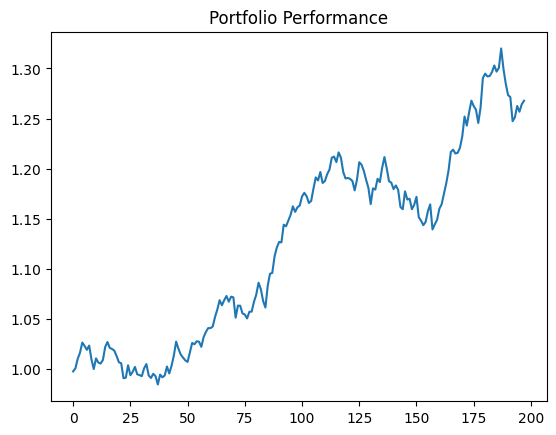

In [8]:
# ===== LAB 7: ML-based Return Prediction + Portfolio Optimization =====
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# ---- Fake multi-stock data ----
np.random.seed(42)
n_assets = 3
prices = np.cumsum(np.random.randn(200, n_assets), axis=0) + 100
df = pd.DataFrame(prices, columns=['A','B','C'])

# ---- Compute returns ----
returns = df.pct_change().dropna()

# ---- Feature engineering (lag) ----
X = returns.shift(1).dropna()
y = returns.loc[X.index]

# ---- Train model (multi-output) ----
model = LinearRegression()
model.fit(X, y)

# ---- Predict returns ----
pred = model.predict(X)

# ---- Optimize weights (maximize expected return) ----
mean_pred = pred.mean(axis=0)
weights = mean_pred / np.sum(np.abs(mean_pred))  # normalize

# ---- Backtest ----
portfolio_return = (returns.loc[X.index].values * weights).sum(axis=1)
cum_return = np.cumprod(1 + portfolio_return)

print("Weights:", weights)
print("Final return:", cum_return[-1])

# ---- Plot ----
import matplotlib.pyplot as plt
plt.plot(cum_return)
plt.title("Portfolio Performance")
plt.show()

LAB 08 – Reinforcement Learning portfolio
• Mục tiêu: RL allocation
• Dữ liệu: Market
• Yêu cầu:
1. Define state/action
2. Train RL
3. Optimize weights
4. Evaluate
5. Analyze 

In [10]:
# ===== LAB 8: RL Portfolio Allocation (Q-learning nhẹ) =====
import numpy as np
import pandas as pd

# ---- Fake data ----
np.random.seed(42)
returns = np.random.randn(200, 3) * 0.01

# ---- State: market trend (up/down) ----
def get_state(r):
    return int(np.mean(r) > 0)

# ---- Actions: chọn asset (0,1,2) ----
Q = np.zeros((2, 3))

alpha = 0.1
gamma = 0.9
epsilon = 0.2

# ---- Training ----
for ep in range(50):
    for t in range(len(returns)-1):
        state = get_state(returns[t])
        
        if np.random.rand() < epsilon:
            action = np.random.randint(3)
        else:
            action = np.argmax(Q[state])
        
        reward = returns[t+1, action]  # return asset chọn
        
        next_state = get_state(returns[t+1])
        
        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

# ---- Extract policy ----
policy = np.argmax(Q, axis=1)

print("Q-table:\n", Q)
print("Policy (state->asset):", policy)

# ---- Backtest ----
portfolio = []
for t in range(len(returns)-1):
    state = get_state(returns[t])
    action = policy[state]
    portfolio.append(returns[t+1, action])

portfolio = np.array(portfolio)
cum = np.cumprod(1 + portfolio)

print("Final return:", cum[-1])

Q-table:
 [[0.00796405 0.00554873 0.00699931]
 [0.00602177 0.00370409 0.00495255]]
Policy (state->asset): [0 0]
Final return: 1.1185316821659372
